# **Imports**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **Data Loading**

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rabieelkharoua/predict-conversion-in-digital-marketing-dataset")

print("Path to dataset files:", path)

c:\Users\Asus\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 529k/529k [00:01<00:00, 512kB/s]

Extracting files...
Path to dataset files: C:\Users\Asus\.cache\kagglehub\datasets\rabieelkharoua\predict-conversion-in-digital-marketing-dataset\versions\1


In [2]:
df = pd.read_csv('digital_marketing_campaign_dataset.csv')
df.head()

,CustomerID,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,AdvertisingPlatform,AdvertisingTool,Conversion
0,8000,56,Female,136912,Social Media,Awareness,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,9,4,688,IsConfid,ToolConfid,1
1,8001,69,Male,41760,Email,Retention,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,7,2,3459,IsConfid,ToolConfid,1
2,8002,46,Female,88456,PPC,Awareness,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,11,2,8,2337,IsConfid,ToolConfid,1
3,8003,32,Female,44085,PPC,Conversion,539.525936,0.137611,0.088004,47,4.540939,14.688363,89,2,2,0,2463,IsConfid,ToolConfid,1
4,8004,60,Female,83964,PPC,Conversion,1678.043573,0.252851,0.109940,0,2.046847,13.993370,6,6,6,8,4345,IsConfid,ToolConfid,1


---

# **Exploratory Data Analysis**

In [3]:
df.shape

(8000, 20)

Checking Each Column Data Type

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           8000 non-null   int64  
 1   Age                  8000 non-null   int64  
 2   Gender               8000 non-null   str    
 3   Income               8000 non-null   int64  
 4   CampaignChannel      8000 non-null   str    
 5   CampaignType         8000 non-null   str    
 6   AdSpend              8000 non-null   float64
 7   ClickThroughRate     8000 non-null   float64
 8   ConversionRate       8000 non-null   float64
 9   WebsiteVisits        8000 non-null   int64  
 10  PagesPerVisit        8000 non-null   float64
 11  TimeOnSite           8000 non-null   float64
 12  SocialShares         8000 non-null   int64  
 13  EmailOpens           8000 non-null   int64  
 14  EmailClicks          8000 non-null   int64  
 15  PreviousPurchases    8000 non-null   int64  
 16 

Changing 'Conversion' column data type to Object

In [5]:
df['Conversion'] = df['Conversion'].astype(object)

In [6]:
df.describe()

,CustomerID,Age,Income,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints
count,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,11999.50000,43.625500,84664.196750,5000.944830,0.154829,0.104389,24.751625,5.549299,7.727718,49.799750,9.476875,4.467375,4.485500,2490.268500
std,2309.54541,14.902785,37580.387945,2838.038153,0.084007,0.054878,14.312269,2.607358,4.228218,28.901165,5.711111,2.856564,2.888093,1429.527162
min,8000.00000,18.000000,20014.000000,100.054813,0.010005,0.010018,0.000000,1.000428,0.501669,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9999.75000,31.000000,51744.500000,2523.221165,0.082635,0.056410,13.000000,3.302479,4.068340,25.000000,5.000000,2.000000,2.000000,1254.750000
50%,11999.50000,43.000000,84926.500000,5013.440044,0.154505,0.104046,25.000000,5.534257,7.682956,50.000000,9.000000,4.000000,4.000000,2497.000000
75%,13999.25000,56.000000,116815.750000,7407.989369,0.228207,0.152077,37.000000,7.835756,11.481468,75.000000,14.000000,7.000000,7.000000,3702.250000
max,15999.00000,69.000000,149986.000000,9997.914781,0.299968,0.199995,49.000000,9.999055,14.995311,99.000000,19.000000,9.000000,9.000000,4999.000000


---

### **Checking for Duplicates and Null values**


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isna().sum()

CustomerID             0
Age                    0
Gender                 0
Income                 0
CampaignChannel        0
CampaignType           0
AdSpend                0
ClickThroughRate       0
ConversionRate         0
WebsiteVisits          0
PagesPerVisit          0
TimeOnSite             0
SocialShares           0
EmailOpens             0
EmailClicks            0
PreviousPurchases      0
LoyaltyPoints          0
AdvertisingPlatform    0
AdvertisingTool        0
Conversion             0
dtype: int64

The dataset has no duplicate or null values to clean

In [9]:
# Just identifier, not useful for us, we can drop

df = df.drop(columns='CustomerID')

### **Categorize Columns To Visualize Distribution**

In [10]:
num_col = df.select_dtypes(include='number').columns
num_col

Index(['Age', 'Income', 'AdSpend', 'ClickThroughRate', 'ConversionRate',
       'WebsiteVisits', 'PagesPerVisit', 'TimeOnSite', 'SocialShares',
       'EmailOpens', 'EmailClicks', 'PreviousPurchases', 'LoyaltyPoints'],
      dtype='str')

In [11]:
cat_col = df.select_dtypes(exclude='number').columns
cat_col

Index(['Gender', 'CampaignChannel', 'CampaignType', 'AdvertisingPlatform',
       'AdvertisingTool', 'Conversion'],
      dtype='str')

### **Distribution of Numerical Columns** / Finding Outliers

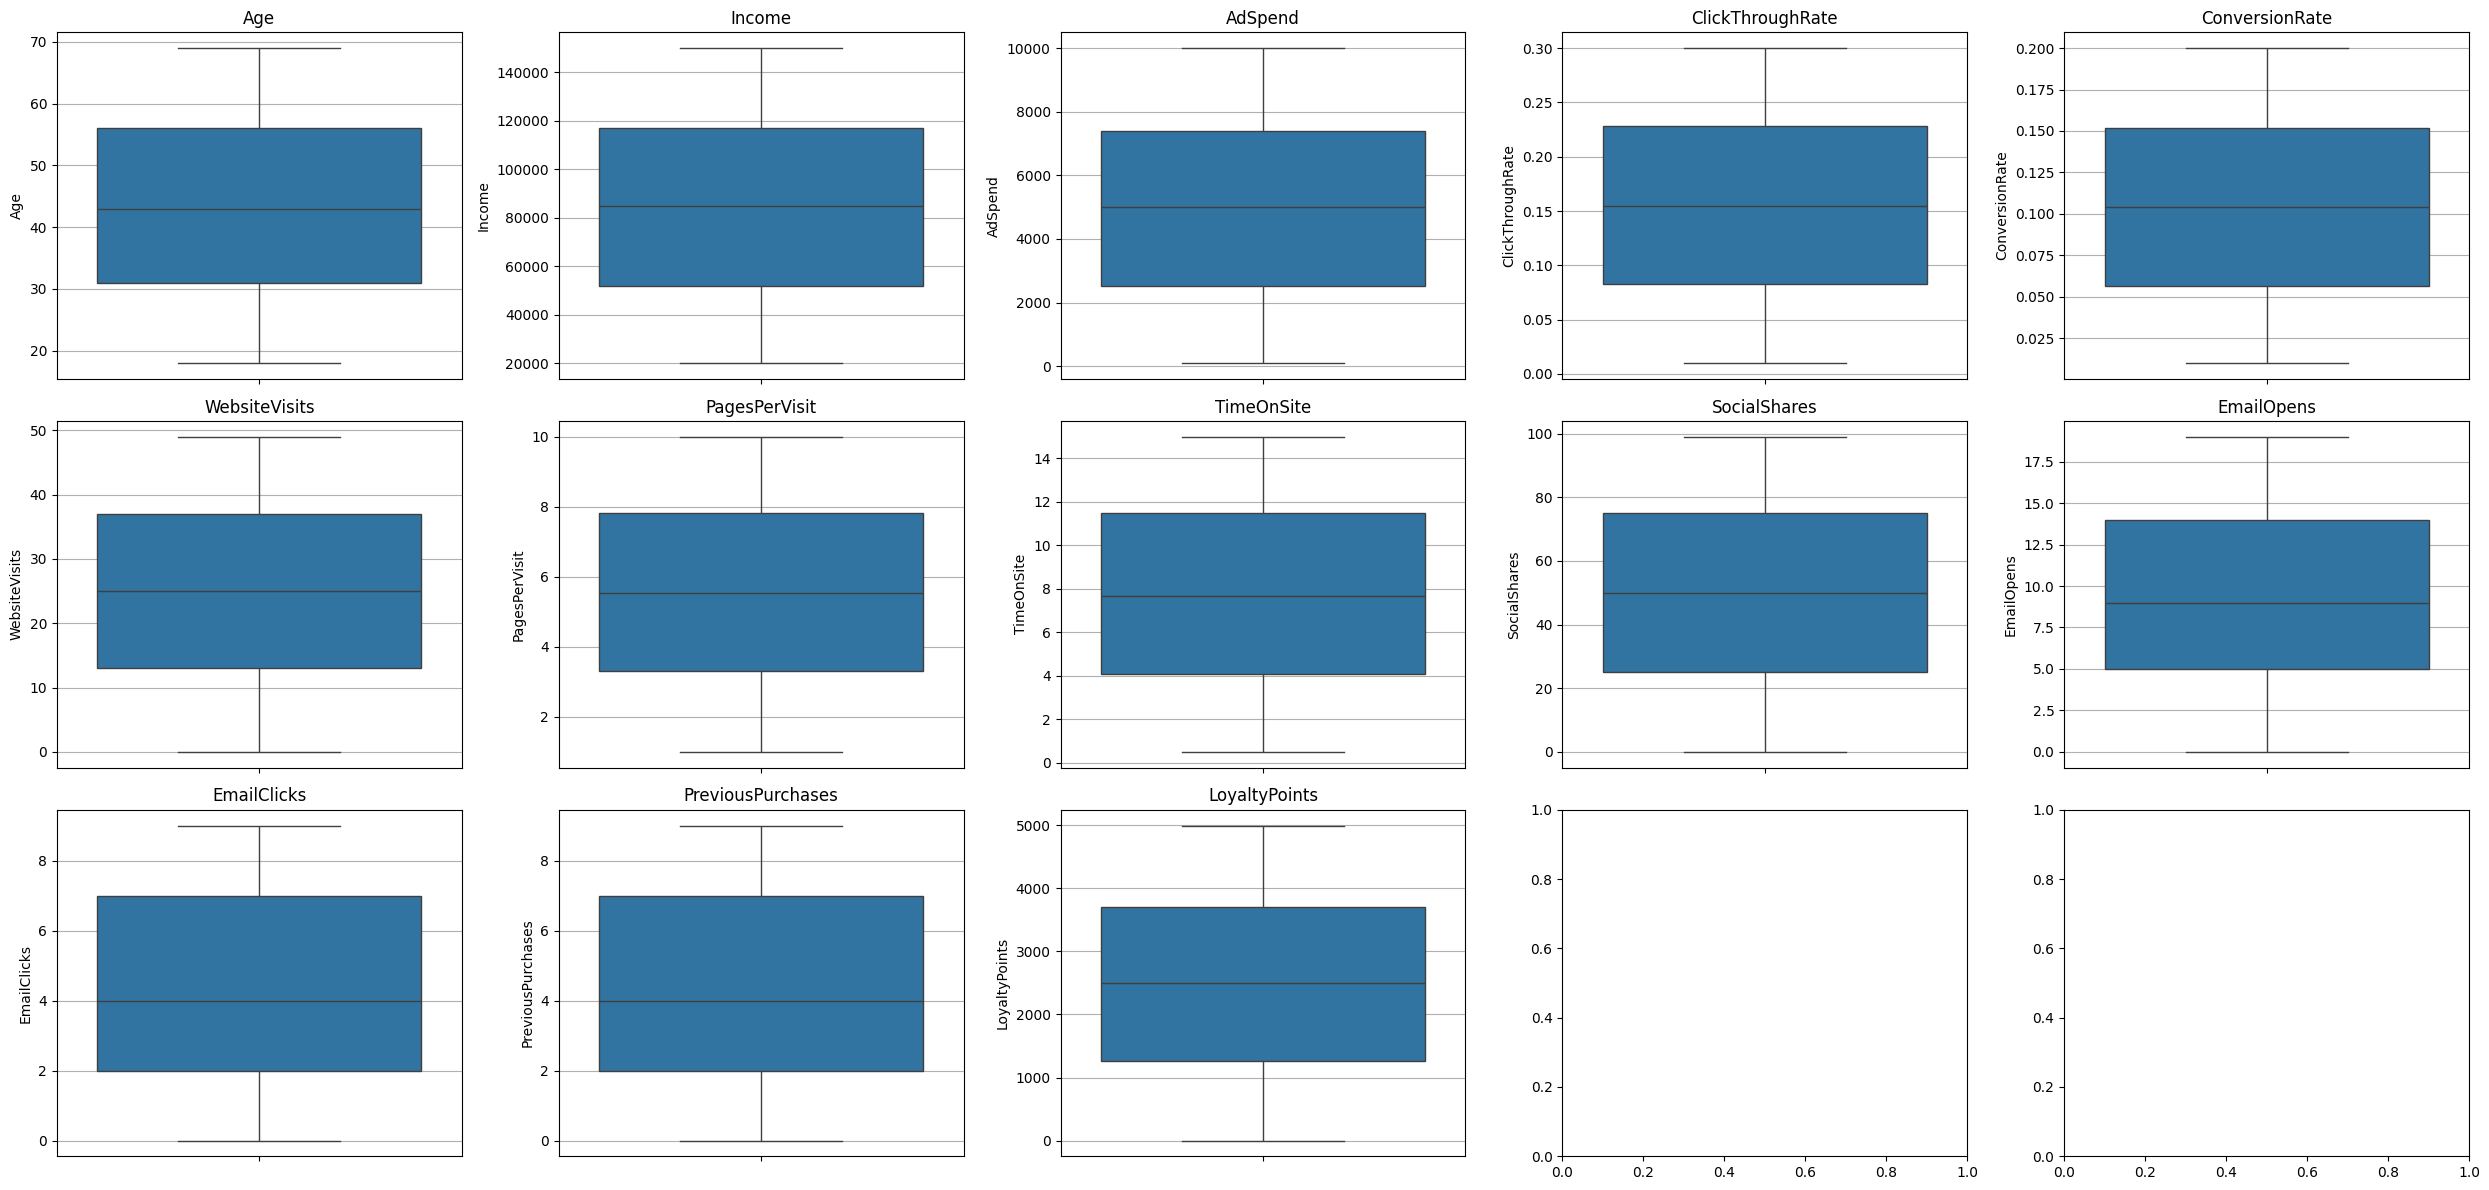

In [12]:
_, axes = plt.subplots(3, 5, figsize=(25, 12))

axes = axes.flatten()

for ax, col in zip(axes, num_col):
    sns.boxplot(df, y=col, ax=ax)
    ax.set_title(col)
    ax.grid(axis='y')
    

plt.tight_layout()
plt.show()

We see all of the numerical columns are mostly normally distributed with no obvious skewness

### **Distribution of Categorical Columns**

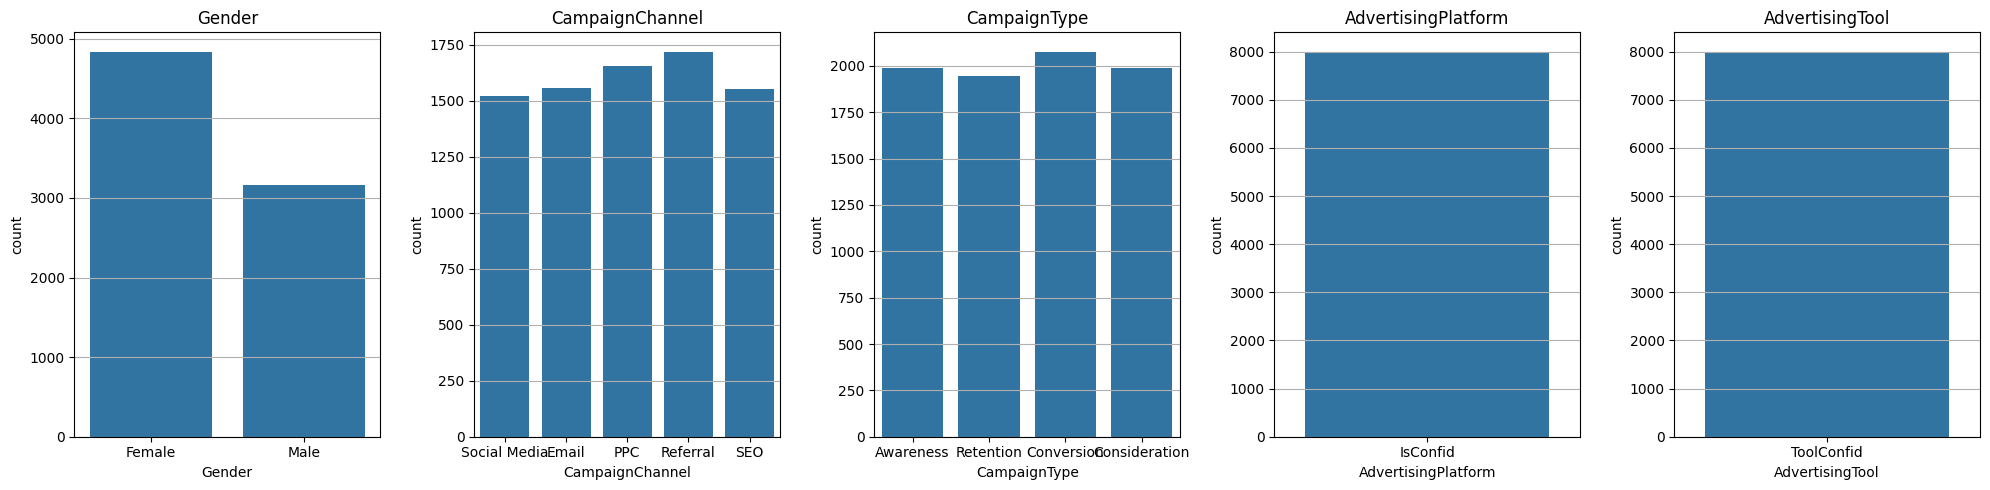

In [13]:
_, axes = plt.subplots(1, 5, figsize=(20, 5))

axes = axes.flatten()

for ax, col in zip(axes, cat_col):
    sns.countplot(df, x=col, ax=ax)
    ax.set_title(col)
    ax.grid(axis='y')
   
plt.tight_layout()
plt.show()

In [14]:
# These two columns is modified as confidential so we can just drop them

df = df.drop(columns=['AdvertisingPlatform', 'AdvertisingTool'])

#### **Summarized Understanding of the Columns**

Demographic Information

- CustomerID: Unique identifier (drop for modeling).
- Age: Numeric (customer age).
- Gender: Categorical (Male/Female).
- Income: Numeric (annual income in USD).

Marketing-specific Variables

- CampaignChannel: Categorical (Email, Social Media, SEO, PPC, Referral).
- CampaignType: Categorical (Awareness, Consideration, Conversion, Retention).
- AdSpend: Numeric (amount spent on the campaign in USD).
- ClickThroughRate: Numeric (CTR, clicks/impressions).
- ConversionRate: Numeric (conversions/clicks).
- AdvertisingPlatform: Confidential (masked — usually safe to drop).
- AdvertisingTool: Confidential (masked — usually safe to drop).

Customer Engagement Variables

- WebsiteVisits: Numeric (total visits to the website).
- PagesPerVisit: Numeric (average pages viewed per session).
- TimeOnSite: Numeric (average time spent per visit in minutes).
- SocialShares: Numeric (number of social media shares).
- EmailOpens: Numeric (number of marketing emails opened).
- EmailClicks: Numeric (number of email links clicked).

Historical Data

- PreviousPurchases: Numeric (count of prior purchases).
- LoyaltyPoints: Numeric (accumulated loyalty points).

Target Variable

- Conversion: Binary (1 = converted, 0 = did not convert)

---

### **Visualize Possible Relationship Between Conversions and Other Columns**

### **Relationship Between Numeric Columns and Conversion**

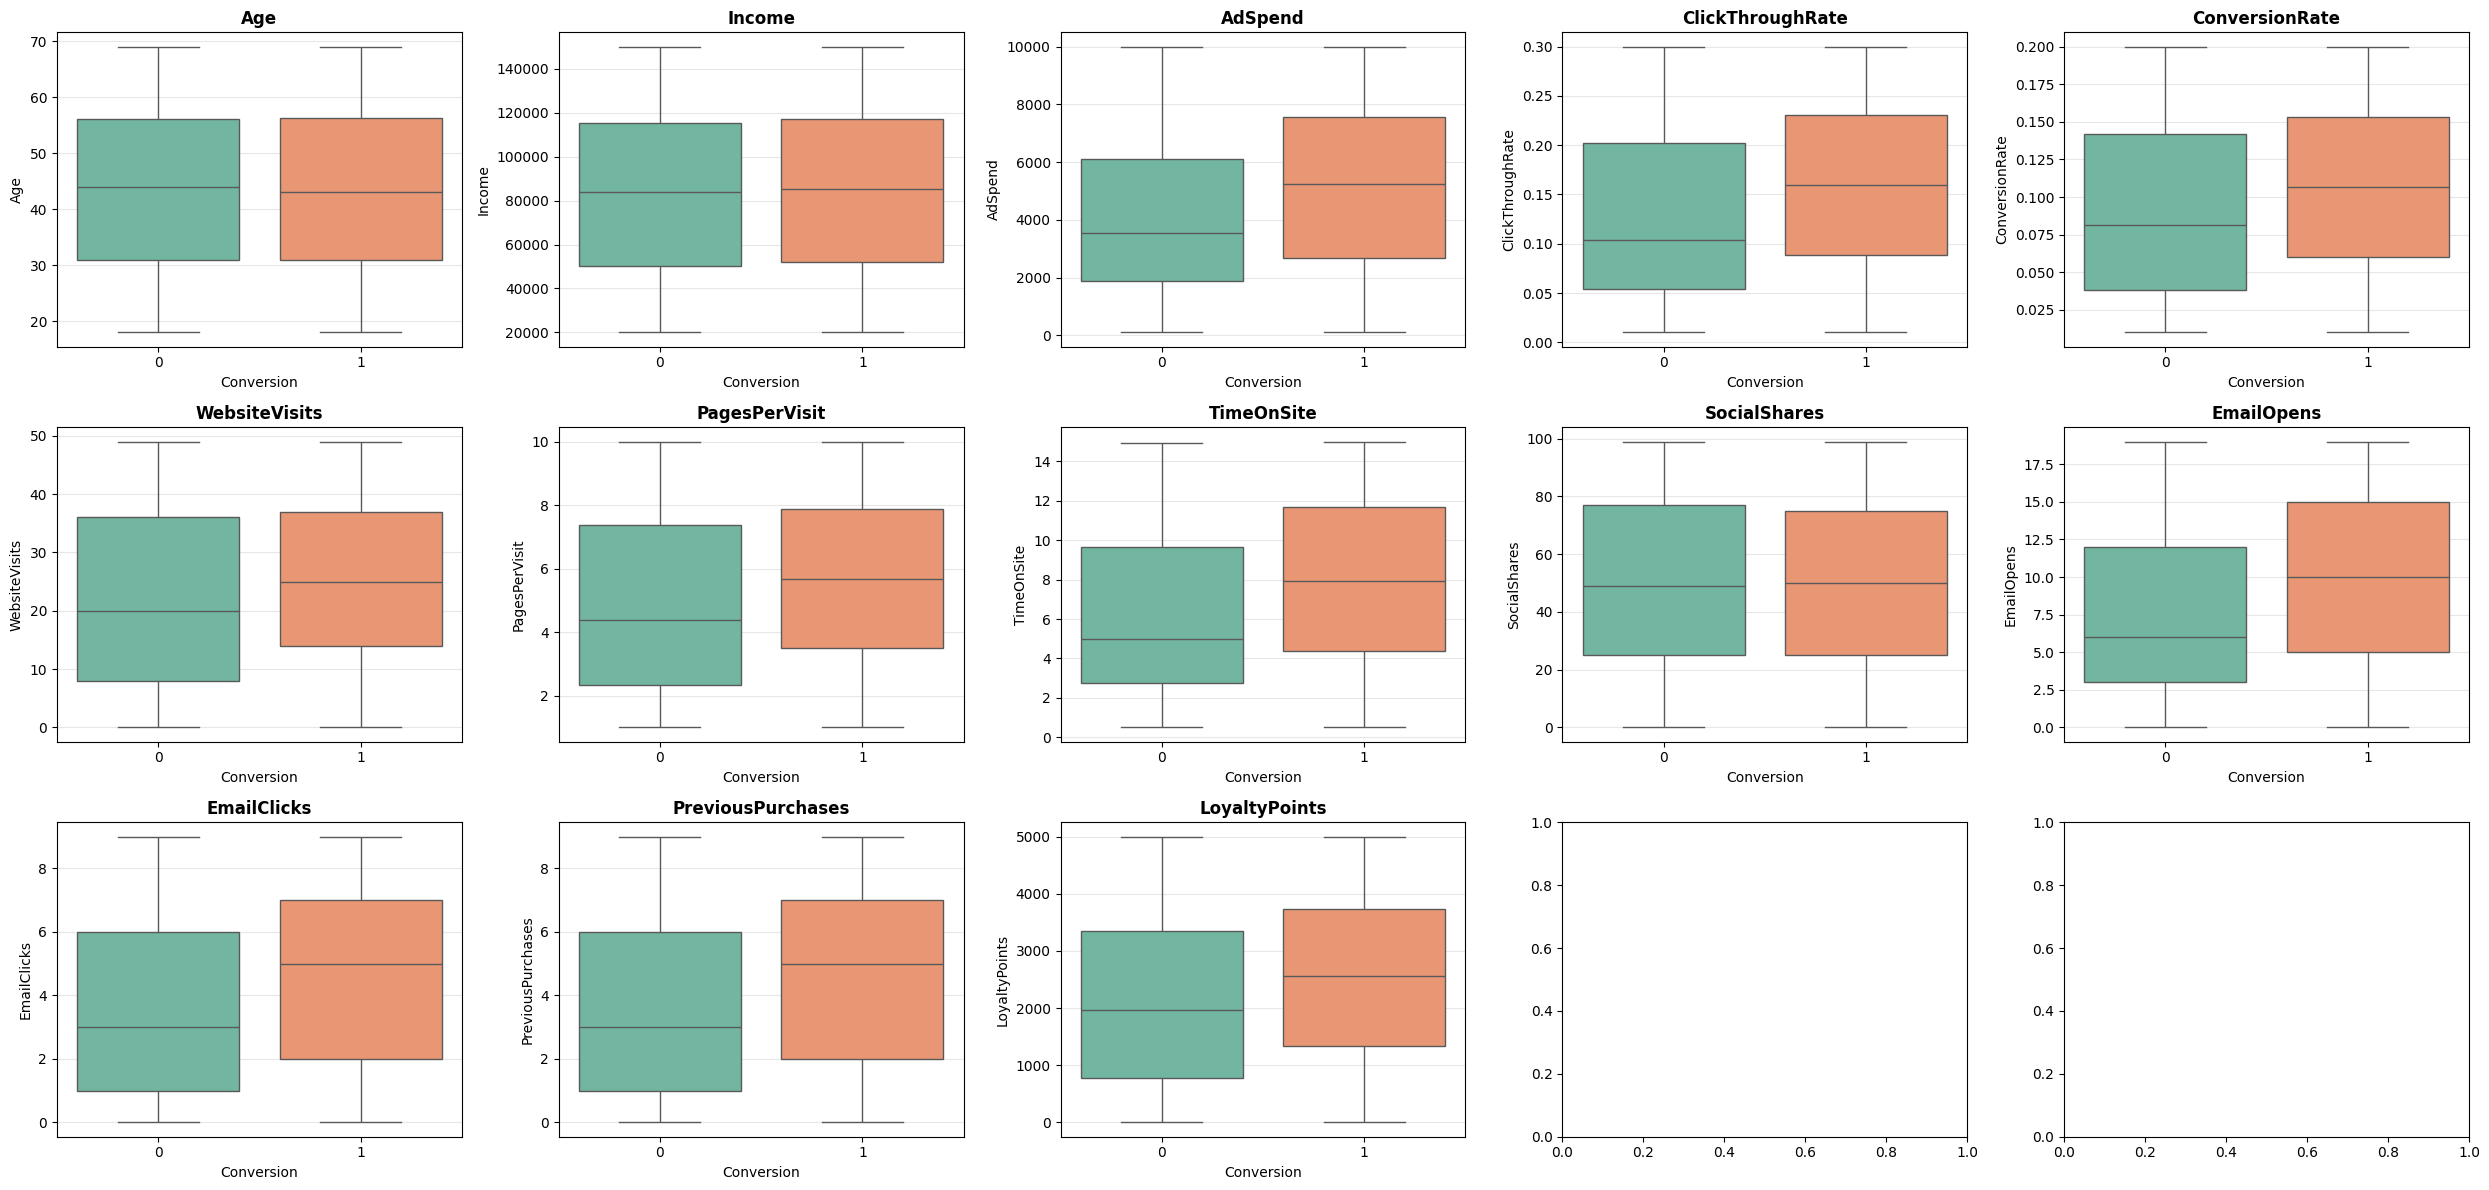

In [15]:
_, axes = plt.subplots(3, 5, figsize=(25, 12))

axes = axes.flatten()

for ax, col in zip(axes, num_col):
    sns.boxplot(data=df, y=col, x='Conversion', hue='Conversion', ax=ax, palette='Set2', legend=False)
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    

plt.tight_layout()
plt.show()

- We can see clear potential relationships between Conversion and some columns like Adspend, click through rate, time on site, emails opened...

In [16]:
cat_col = df.select_dtypes(exclude='number').columns.drop('Conversion')
cat_col

Index(['Gender', 'CampaignChannel', 'CampaignType'], dtype='str')

### **Relationship Between Categorical Columns and Conversion**

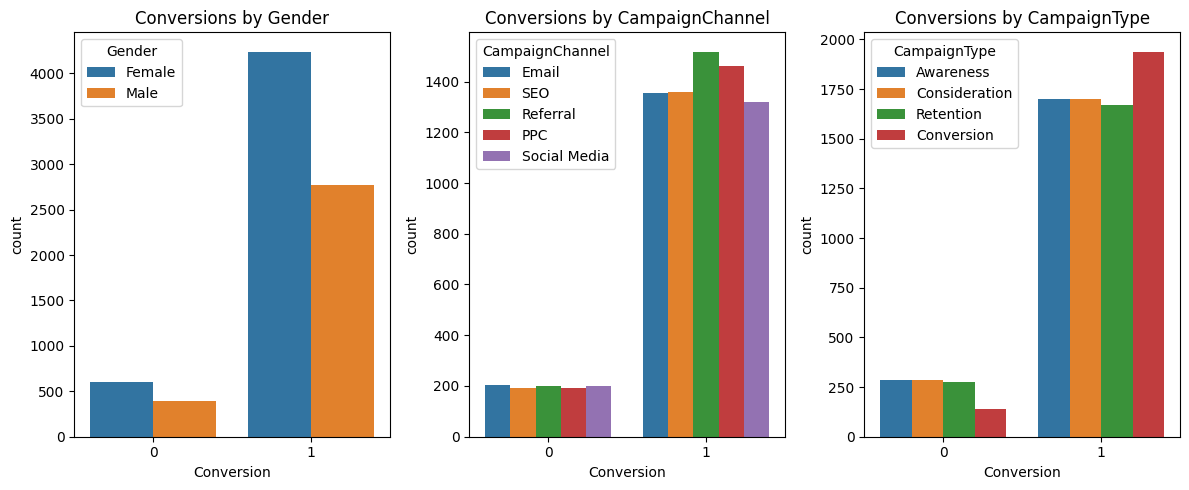

In [17]:
_, axes = plt.subplots(1, 3, figsize=(12, 5))
axes = axes.flatten()

for ax, col in zip(axes, cat_col):
    sns.countplot(df, x='Conversion', hue=col , ax=ax)
    ax.set_title(f'Conversions by {col}')
plt.tight_layout()
plt.show()

- We can see potential relationship between conversion and some campaign channels like Referal and PPC and some campaign types like conversion.

-> But we will input all of them into our model and let it decide which ones are the most important for now

---

# **Data Preprocessing**

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

### **Hot One Encoding the categorical columns using pandas get_dummies function**

In [19]:
# One line version using pandas (very simple)
df = pd.get_dummies(df, columns=cat_col, drop_first=True, dtype='int8')

In [20]:
print("One-Hot Encoding done!")
df.head()

One-Hot Encoding done!


,Age,Income,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,...,LoyaltyPoints,Conversion,Gender_Male,CampaignChannel_PPC,CampaignChannel_Referral,CampaignChannel_SEO,CampaignChannel_Social Media,CampaignType_Consideration,CampaignType_Conversion,CampaignType_Retention
0,56,136912,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,...,688,1,0,0,0,0,1,0,0,0
1,69,41760,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,...,3459,1,1,0,0,0,0,0,0,1
2,46,88456,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,11,...,2337,1,0,1,0,0,0,0,0,0
3,32,44085,539.525936,0.137611,0.088004,47,4.540939,14.688363,89,2,...,2463,1,0,1,0,0,0,0,1,0
4,60,83964,1678.043573,0.252851,0.109940,0,2.046847,13.993370,6,6,...,4345,1,0,1,0,0,0,0,1,0


### **Standardization**

In [21]:
df[num_col].skew()

Age                 -0.004916
Income              -0.011298
AdSpend              0.019224
ClickThroughRate     0.011066
ConversionRate       0.012777
WebsiteVisits       -0.017139
PagesPerVisit       -0.012510
TimeOnSite           0.014610
SocialShares        -0.011357
EmailOpens           0.007679
EmailClicks          0.023366
PreviousPurchases    0.005712
LoyaltyPoints        0.016303
dtype: float64

Although the columns doesn't seem to have that much skewness and quite normally dsitributed, we still need to do standardization for the numerical columns because they are on very different scales and we will be using some models that is sensitive to feature scaling. We will use StandardScaler to standardize the numerical features.

In [22]:
scaler = StandardScaler()

df[num_col] = scaler.fit_transform(df[num_col])

In [23]:
df.head()

,Age,Income,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,...,LoyaltyPoints,Conversion,Gender_Male,CampaignChannel_PPC,CampaignChannel_Referral,CampaignChannel_SEO,CampaignChannel_Social Media,CampaignType_Consideration,CampaignType_Conversion,CampaignType_Retention
0,0.830400,1.390381,0.527484,-1.320328,-0.298084,-1.729507,-1.208303,-0.078268,-1.065759,-0.608829,...,-1.260823,1,0,0,0,0,1,0,0,0
1,1.702775,-1.141736,-0.388418,0.010671,1.427538,1.205221,-1.009576,-0.561778,-1.550199,-1.309262,...,0.677701,1,1,0,0,0,0,0,0,1
2,0.159343,0.100905,-1.217296,1.460225,-0.509632,-1.589758,1.025746,1.435016,-1.723213,0.266712,...,-0.107223,1,0,1,0,0,0,0,0,0
3,-0.780138,-1.079865,-1.572106,-0.204964,-0.298580,1.554594,-0.386761,1.646339,1.356440,-1.309262,...,-0.019076,1,0,1,0,0,0,0,1,0
4,1.098823,-0.018633,-1.170918,1.166907,0.101164,-1.729507,-1.343379,1.481958,-1.515596,-0.608829,...,1.297525,1,0,1,0,0,0,0,1,0


---

# **Exploratory Data Analysis**

---

## **Spliting Data For Training**

In [24]:
# Choosing all the columns as features for now

X = df.drop("Conversion", axis=1)

In [25]:
# Choosing conversion as the label to predict

y = df['Conversion']
y = y.astype('int')

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [27]:
X_train.shape

(6400, 21)

In [28]:
y_train.shape

(6400,)

In [29]:
y_train.value_counts()

Conversion
1    5610
0     790
Name: count, dtype: int64

In [30]:
y_test.value_counts()

Conversion
1    1402
0     198
Name: count, dtype: int64

---

# **Building The Model**

### **Goal** : Build a model to classify a row of customer data as 0 or 1 (Converted or Not)

- Because we have multiple columns that don't visually have clear relationship to the target column, we need a model that can capture the potential complicated relatioship they have to conversion

- We can do so by testing and comparing between these widely used models for such cases

    - Linear/Simple: Logistic Regression, Gaussian Naive Bayes
    - Tree-based: Decision Tree, Random Forest
    - Boosting: Gradient Boosting, AdaBoost, XGBoost
    - Instance-based: K-Nearest Neighbors
    - Deep Learning: Sequential Neural Network (Sigmoid)


### **Importing the Models**

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier, plot_importance

### **Importing the Metrics**

In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report, precision_score, recall_score, f1_score, roc_curve, auc
from copy import deepcopy

In [33]:
# Function to train, test, and evaluate the model

results = []

def model_functionality(model, x_train, y_train, x_test, y_test, model_name):
    class_model = model
    class_model.fit(x_train, y_train)

    # Predict on the test set
    predicted_y_test = class_model.predict(x_test)

    # Calculate accuracy
    accuracy_test = accuracy_score(y_test, predicted_y_test)
    print(f'Accuracy on test data: {accuracy_test * 100:.0f}%\n')

    # Calculate F1 Score
    f1_test = f1_score(y_test, predicted_y_test)
    print(f'F1 Score on test data: {f1_test:.2f}\n')

    # Display classification report
    report = classification_report(y_test, predicted_y_test, output_dict=True)
    report_table = classification_report(y_test, predicted_y_test)
    print(f"Classification Report for {model_name}:\n\n{report_table}\n")

    results.append({
        'Model': name,
        'Accuracy': report['accuracy'],
        'Class 0 Precision': report['0']['precision'],
        'Class 0 Recall':    report['0']['recall'],
        'Class 0 F1':        report['0']['f1-score'],
        'Class 1 Precision': report['1']['precision'],
        'Class 1 Recall':    report['1']['recall'],
        'Class 1 F1':        report['1']['f1-score'],
        'Macro Avg F1':      report['macro avg']['f1-score']
    })

    y_prob = (class_model.predict_proba(x_test)[:, 1]
              if hasattr(class_model, "predict_proba")
              else class_model.decision_function(x_test))
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    roc_data[model_name] = (fpr, tpr, roc_auc)

    return class_model

# Models to test
models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'AdaBoost': AdaBoostClassifier(),
    'XGBoost': XGBClassifier(),
    'Random Forest': RandomForestClassifier(),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Gaussian Naive Bayes': GaussianNB(),
}

# Train each model 
roc_data = {}
for name, model in models.items():
    trained_model = model_functionality(model, X_train, y_train, X_test, y_test, name)

Accuracy on test data: 89%

F1 Score on test data: 0.94

Classification Report for Logistic Regression:

              precision    recall  f1-score   support

           0       0.77      0.17      0.28       198
           1       0.89      0.99      0.94      1402

    accuracy                           0.89      1600
   macro avg       0.83      0.58      0.61      1600
weighted avg       0.88      0.89      0.86      1600


Accuracy on test data: 83%

F1 Score on test data: 0.90

Classification Report for Decision Tree:

              precision    recall  f1-score   support

           0       0.33      0.35      0.34       198
           1       0.91      0.90      0.90      1402

    accuracy                           0.83      1600
   macro avg       0.62      0.63      0.62      1600
weighted avg       0.84      0.83      0.84      1600


Accuracy on test data: 91%

F1 Score on test data: 0.95

Classification Report for Gradient Boosting:

              precision    recall  f1

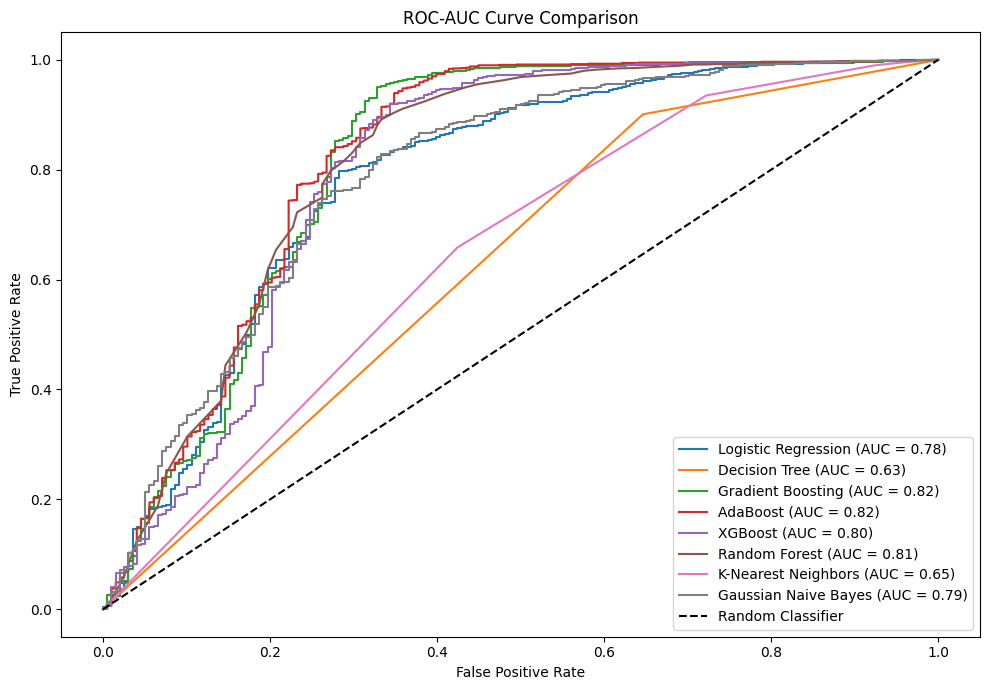

In [36]:
# Plot all ROC curves on one chart
plt.figure(figsize=(10, 7))
for model_name, (fpr, tpr, roc_auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve Comparison')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [37]:
# Convert to DataFrame
results_df = pd.DataFrame(results)
print(results_df.round(4))

                  Model  Accuracy  Class 0 Precision  Class 0 Recall  \
0   Logistic Regression    0.8912             0.7727          0.1717   
1         Decision Tree    0.8331             0.3349          0.3535   
2     Gradient Boosting    0.9100             0.8462          0.3333   
3              AdaBoost    0.8994             0.8776          0.2172   
4               XGBoost    0.9144             0.8144          0.3990   
5         Random Forest    0.8919             0.8571          0.1515   
6   K-Nearest Neighbors    0.8769             0.5172          0.0758   
7  Gaussian Naive Bayes    0.8900             0.8056          0.1465   

   Class 0 F1  Class 1 Precision  Class 1 Recall  Class 1 F1  Macro Avg F1  
0      0.2810             0.8946          0.9929      0.9412        0.6111  
1      0.3440             0.9080          0.9009      0.9044        0.6242  
2      0.4783             0.9133          0.9914      0.9508        0.7145  
3      0.3482             0.9001          0

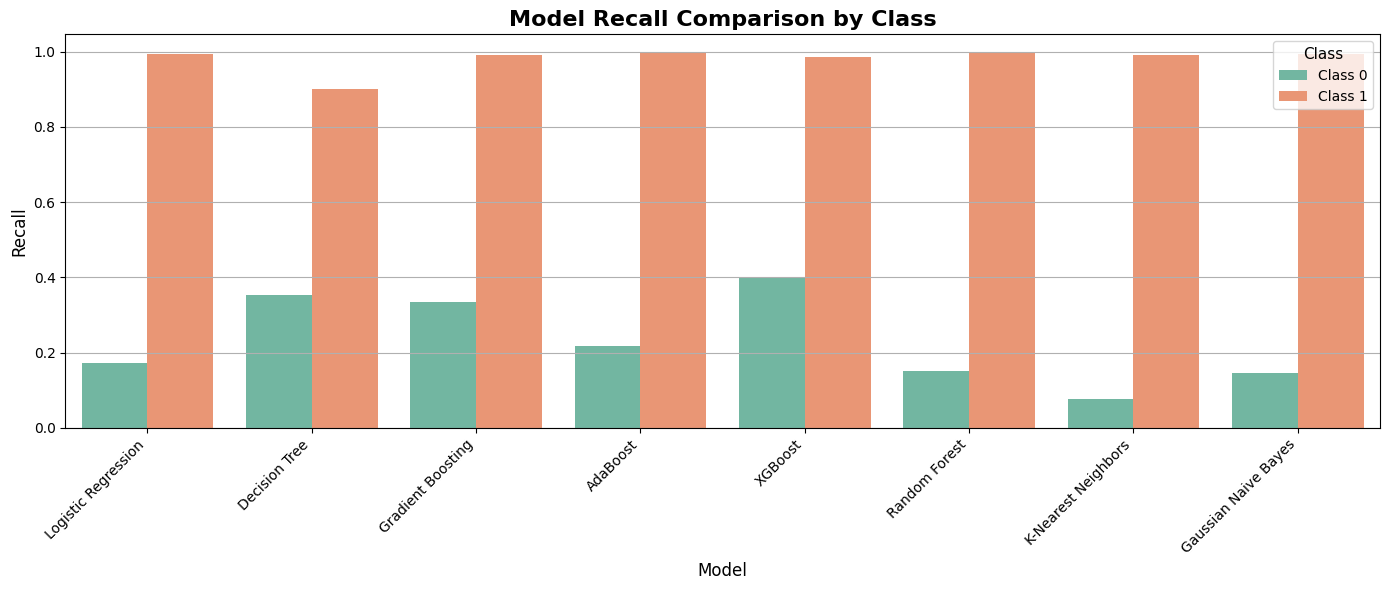

In [38]:
# Visualize Recall by Model and Class
results_df = pd.DataFrame(results)
# Reshape data for seaborn barplot
recall_data = []
for _, row in results_df.iterrows():
    recall_data.append({'Model': row['Model'], 'Class': 'Class 0', 'Recall': row['Class 0 Recall']})
    recall_data.append({'Model': row['Model'], 'Class': 'Class 1', 'Recall': row['Class 1 Recall']})

recall_df = pd.DataFrame(recall_data)

plt.figure(figsize=(14, 6))
sns.barplot(data=recall_df, x='Model', y='Recall', hue='Class', palette='Set2')
plt.title('Model Recall Comparison by Class', fontsize=16, fontweight='bold')
plt.xlabel('Model', fontsize=12)
plt.ylabel('Recall', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Class', title_fontsize=11)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

- From these metrics of each model classification report, we can see that most of the model have a decently high accurracy of over 86% and decent f1-score as well.

- But this is not to be trusted, if we look at the recall and precision of each class, we see it doing very well in predicting the 1 class (converted) but very bad at predicting the 0 class (not converted). 

- This is usually caused by an imbalaced in the dataset classes, where there may be much more converted customers than not converted customers, which causes the model to be biased towards predicting the majority class (converted) and not learning enough about the minority class (not converted)

### **Investigating the Class Imbalance**

In [39]:
df['Conversion'].value_counts()

Conversion
1    7012
0     988
Name: count, dtype: int64

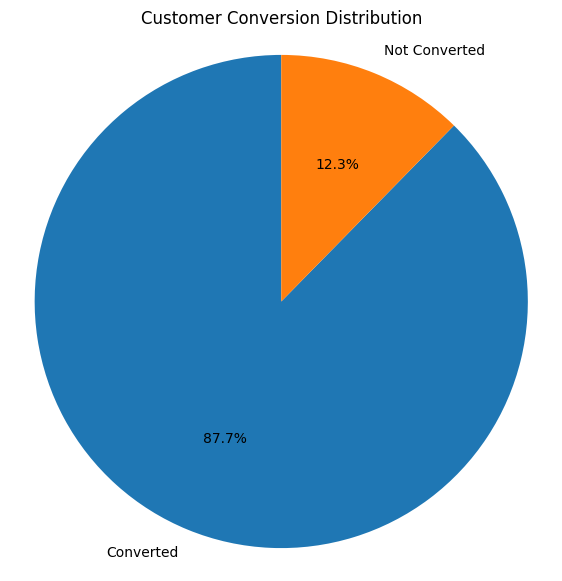

In [40]:
labels = ['Converted', 'Not Converted']
values = df['Conversion'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title("Customer Conversion Distribution")
plt.axis('equal') 
plt.show()

We have a large class imbalance of 7012 & 988 in the dataset, and this is carried through to our training set as well. This leads to the model being biased towards predicting the majority class (converted) and not learning enough about the minority class (not converted), which is why we see such a high precision and recall for the 1 class but very low for the 0 class.

### **Dealing with Class Imbalance with Resampling**

To solve this, we need to resample the dataset to balance the classes, either by 
- undersampling the majority class (converted)
- oversampling the minority class (not converted)
- or using techniques like SMOTE to generate synthetic samples for the minority class. This will help the model learn to predict both classes more effectively and improve the recall and precision for the not converted class. 

### **Considerations in Resampling**
- Undersampling the majority class (converted) can lead to loss of valuable information and may not be ideal
- Oversampling the minority class (not converted) can lead to overfitting, as the model may learn to predict the duplicated samples rather than generalizing from the data
- SMOTE can be a good option as it generates synthetic samples rather than duplicating existing ones, which can help improve the model's ability to generalize and predict the minority class (not converted) more effectively.

In [41]:
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN

---


**RandomUnderSampler**

In [42]:
unique, counts = np.unique(y_train, return_counts=True)
print("Before:\n", y_train.value_counts())


rus = RandomUnderSampler(random_state=1234)
X_train_resampled, y_train_resampled = rus.fit_resample(X_train, y_train)


unique_resampled, counts_resampled = np.unique(y_train_resampled, return_counts=True)
print("After:\n", y_train_resampled.value_counts())

Before:
 Conversion
1    5610
0     790
Name: count, dtype: int64
After:
 Conversion
0    790
1    790
Name: count, dtype: int64


In [43]:
results = []

# Train each model and store results
roc_data = {}
for name, model in models.items():
    print(f"{'-' * 100}\n\n--{name}--\n")
    trained_model = model_functionality(model, X_train_resampled, y_train_resampled, X_test, y_test, name)

----------------------------------------------------------------------------------------------------

--Logistic Regression--

Accuracy on test data: 73%

F1 Score on test data: 0.82

Classification Report for Logistic Regression:

              precision    recall  f1-score   support

           0       0.28      0.73      0.40       198
           1       0.95      0.73      0.82      1402

    accuracy                           0.73      1600
   macro avg       0.61      0.73      0.61      1600
weighted avg       0.87      0.73      0.77      1600


----------------------------------------------------------------------------------------------------

--Decision Tree--

Accuracy on test data: 64%

F1 Score on test data: 0.76

Classification Report for Decision Tree:

              precision    recall  f1-score   support

           0       0.20      0.64      0.31       198
           1       0.93      0.64      0.76      1402

    accuracy                           0.64      1600
  

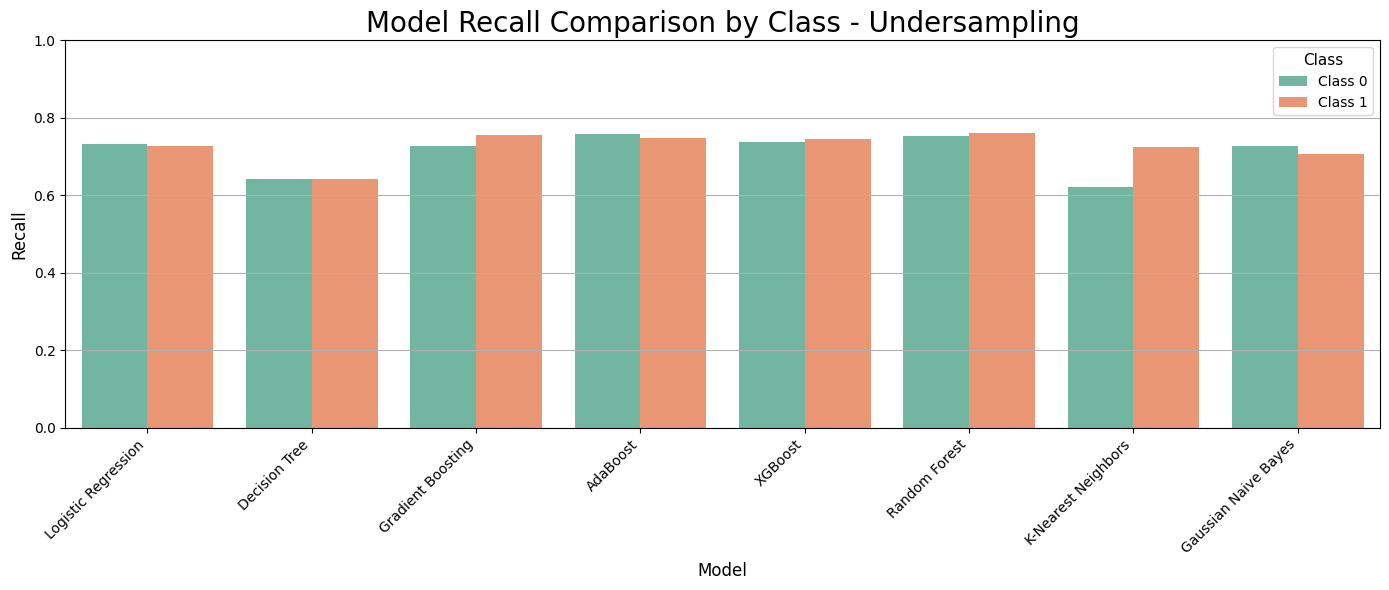

In [44]:
# Visualize Recall by Model and Class
results_df = pd.DataFrame(results)
# Reshape data for seaborn barplot
recall_data = []
for _, row in results_df.iterrows():
    recall_data.append({'Model': row['Model'], 'Class': 'Class 0', 'Recall': row['Class 0 Recall']})
    recall_data.append({'Model': row['Model'], 'Class': 'Class 1', 'Recall': row['Class 1 Recall']})

recall_df = pd.DataFrame(recall_data)

plt.figure(figsize=(14, 6))
sns.barplot(data=recall_df, x='Model', y='Recall', hue='Class', palette='Set2', errorbar=None)
plt.title('Model Recall Comparison by Class - Undersampling', fontsize=20,)
plt.ylim(0, 1)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Recall', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Class', title_fontsize=11)
plt.grid(axis='y')
plt.tight_layout()
plt.show()



---


**RandomOverSampler**



In [45]:
unique, counts = np.unique(y_train, return_counts=True)
print("Before:\n", y_train.value_counts())


ros = RandomOverSampler(random_state=1234)
X_train_resampled, y_train_resampled = ros.fit_resample(X_train, y_train)


unique_resampled, counts_resampled = np.unique(y_train_resampled, return_counts=True)
print("After:\n", y_train_resampled.value_counts())

Before:
 Conversion
1    5610
0     790
Name: count, dtype: int64
After:
 Conversion
1    5610
0    5610
Name: count, dtype: int64


In [46]:
# Train each model and store results

results = []

all_trained_models = {}
for name, model in models.items():
    print(f"{'-' * 100}\n\n--{name}--\n")
    trained_model = model_functionality(model, X_train_resampled, y_train_resampled, X_test, y_test, name)
    all_trained_models[name] = deepcopy(trained_model)

----------------------------------------------------------------------------------------------------

--Logistic Regression--

Accuracy on test data: 76%

F1 Score on test data: 0.85

Classification Report for Logistic Regression:

              precision    recall  f1-score   support

           0       0.30      0.73      0.43       198
           1       0.95      0.76      0.85      1402

    accuracy                           0.76      1600
   macro avg       0.63      0.75      0.64      1600
weighted avg       0.87      0.76      0.79      1600


----------------------------------------------------------------------------------------------------

--Decision Tree--

Accuracy on test data: 84%

F1 Score on test data: 0.91

Classification Report for Decision Tree:

              precision    recall  f1-score   support

           0       0.36      0.34      0.35       198
           1       0.91      0.91      0.91      1402

    accuracy                           0.84      1600
  

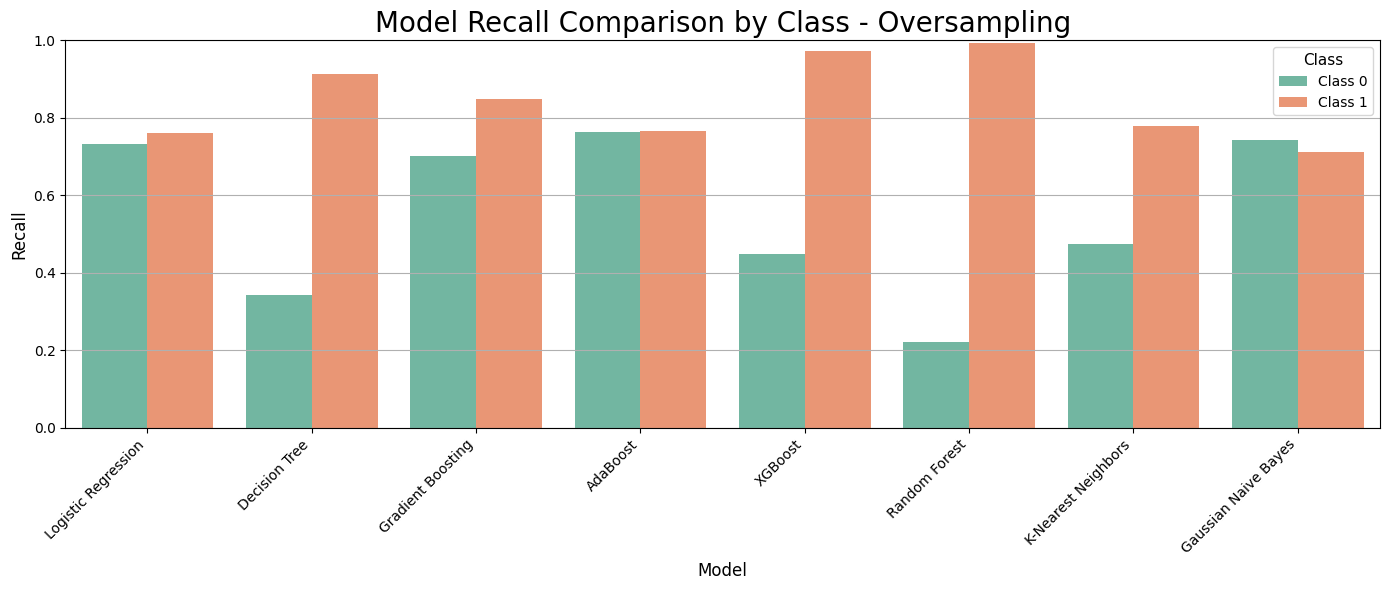

In [47]:
# Visualize Recall by Model and Class
results_df = pd.DataFrame(results)
# Reshape data for seaborn barplot
recall_data = []
for _, row in results_df.iterrows():
    recall_data.append({'Model': row['Model'], 'Class': 'Class 0', 'Recall': row['Class 0 Recall']})
    recall_data.append({'Model': row['Model'], 'Class': 'Class 1', 'Recall': row['Class 1 Recall']})

recall_df = pd.DataFrame(recall_data)

plt.figure(figsize=(14, 6))
sns.barplot(data=recall_df, x='Model', y='Recall', hue='Class', palette='Set2', errorbar=None)
plt.title('Model Recall Comparison by Class - Oversampling', fontsize=20,)
plt.ylim(0, 1)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Recall', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Class', title_fontsize=11)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

---

**SMOTE**

In [48]:
unique, counts = np.unique(y_train, return_counts=True)
print("Before SMOTE:\n", y_train.value_counts())


smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)


unique_resampled, counts_resampled = np.unique(y_train_resampled, return_counts=True)
print("Before SMOTE:\n", y_train_resampled.value_counts())

Before SMOTE:
 Conversion
1    5610
0     790
Name: count, dtype: int64
Before SMOTE:
 Conversion
1    5610
0    5610
Name: count, dtype: int64


In [49]:
# Train each model and store results
results = []
roc_data={}
all_trained_models = {}
for name, model in models.items():
    print(f"{'-' * 100}\n\n--{name}--\n")
    trained_model = model_functionality(model, X_train_resampled, y_train_resampled, X_test, y_test, name)
    all_trained_models[name] = deepcopy(trained_model)


----------------------------------------------------------------------------------------------------

--Logistic Regression--

Accuracy on test data: 81%

F1 Score on test data: 0.89

Classification Report for Logistic Regression:

              precision    recall  f1-score   support

           0       0.32      0.47      0.38       198
           1       0.92      0.86      0.89      1402

    accuracy                           0.81      1600
   macro avg       0.62      0.66      0.63      1600
weighted avg       0.85      0.81      0.82      1600


----------------------------------------------------------------------------------------------------

--Decision Tree--

Accuracy on test data: 80%

F1 Score on test data: 0.88

Classification Report for Decision Tree:

              precision    recall  f1-score   support

           0       0.30      0.44      0.36       198
           1       0.92      0.85      0.88      1402

    accuracy                           0.80      1600
  

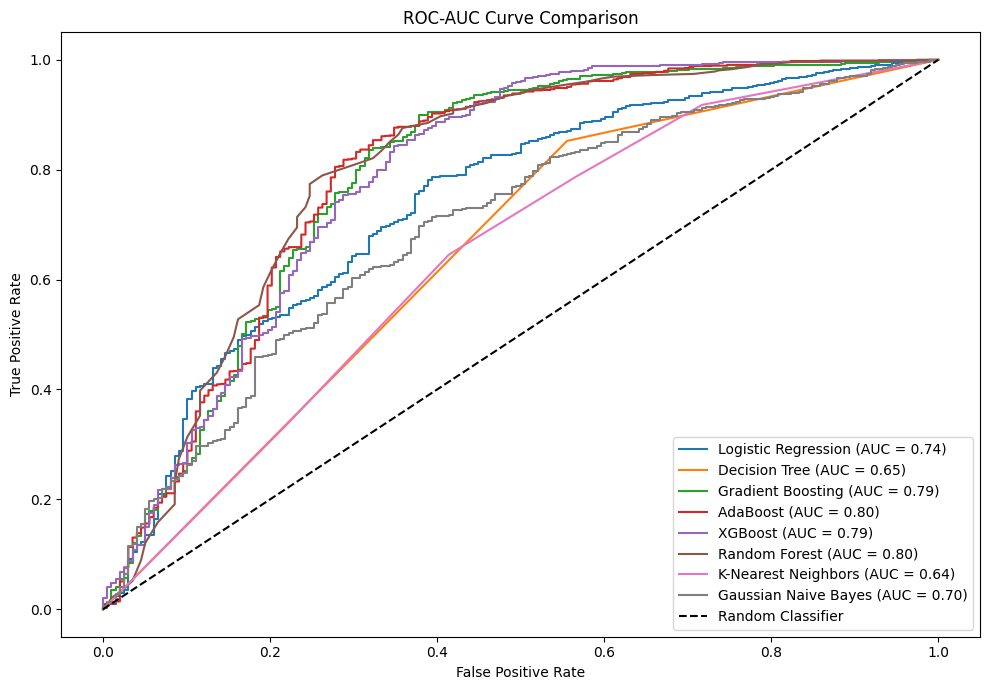

In [50]:
# Plot all ROC curves on one chart
plt.figure(figsize=(10, 7))
for model_name, (fpr, tpr, roc_auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve Comparison')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

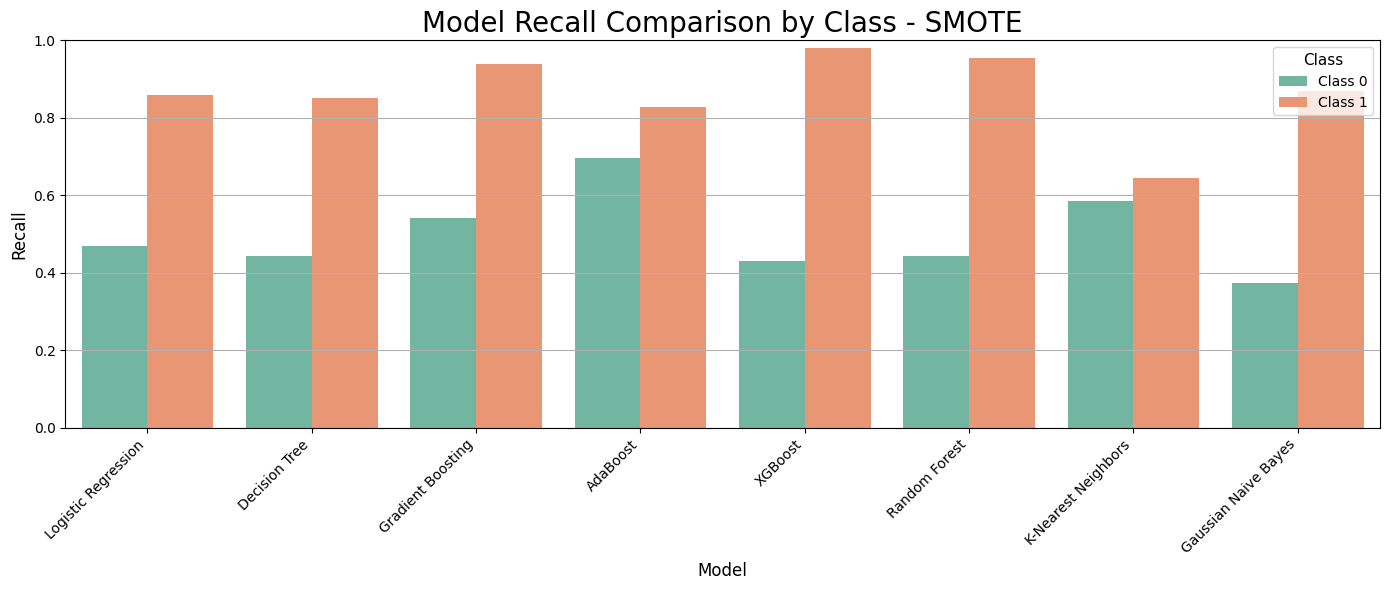

In [51]:
# Visualize Recall by Model and Class
results_df = pd.DataFrame(results)
# Reshape data for seaborn barplot
recall_data = []
for _, row in results_df.iterrows():
    recall_data.append({'Model': row['Model'], 'Class': 'Class 0', 'Recall': row['Class 0 Recall']})
    recall_data.append({'Model': row['Model'], 'Class': 'Class 1', 'Recall': row['Class 1 Recall']})

recall_df = pd.DataFrame(recall_data)

plt.figure(figsize=(14, 6))
sns.barplot(data=recall_df, x='Model', y='Recall', hue='Class', palette='Set2', errorbar=None)
plt.title('Model Recall Comparison by Class - SMOTE', fontsize=20,)
plt.ylim(0, 1)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Recall', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Class', title_fontsize=11)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

C:\Users\Asus\AppData\Local\Temp\ipykernel_16056\500595965.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Model', y='Macro Avg F1', palette='husl', errorbar=None)


C:\Users\Asus\AppData\Local\Temp\ipykernel_16056\500595965.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Model', y='Macro Avg F1', palette='husl', errorbar=None)


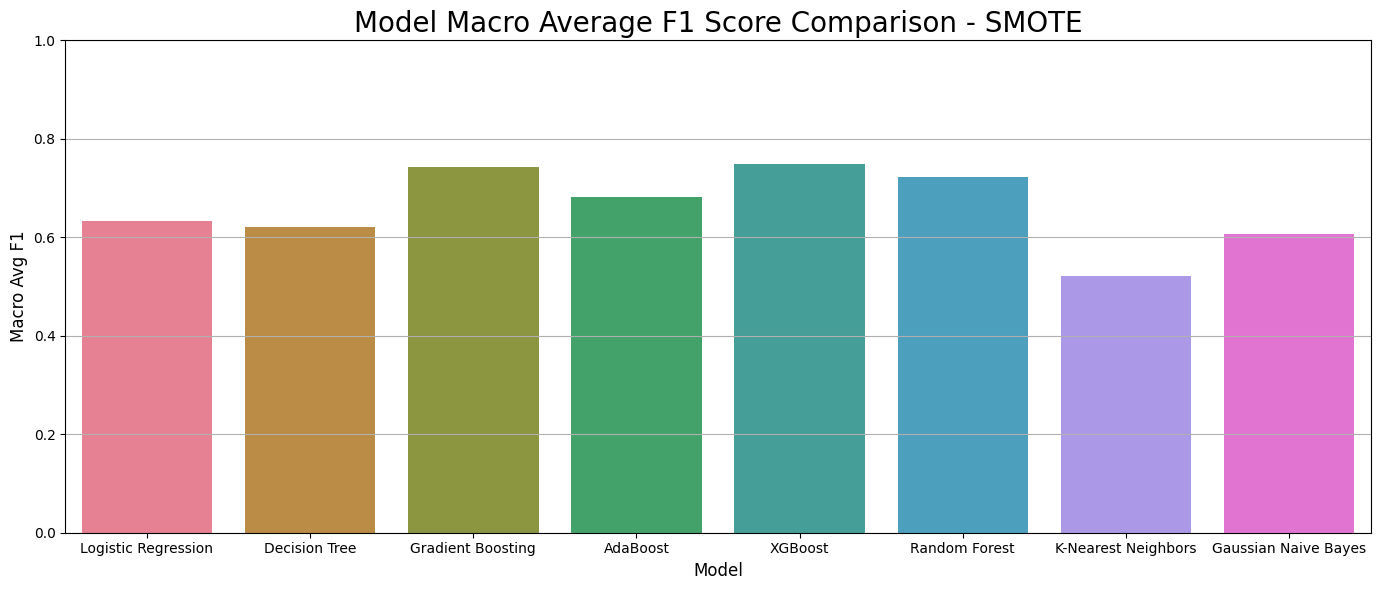

In [52]:
# Visualize Macro Avg F1 by Model
plt.figure(figsize=(14, 6))
sns.barplot(data=results_df, x='Model', y='Macro Avg F1', palette='husl', errorbar=None)
plt.title('Model Macro Average F1 Score Comparison - SMOTE', fontsize=20)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Macro Avg F1', fontsize=12)
plt.ylim(0,1)
plt.xticks(rotation=0, ha='center')
plt.grid(axis='y')
plt.tight_layout()
plt.show()


---


**SMOTEENN**

In [53]:
unique, counts = np.unique(y_train, return_counts=True)
print("Before:\n", y_train.value_counts())


smote_enn = SMOTEENN(random_state=1234)
X_train_resampled, y_train_resampled = smote_enn.fit_resample(X_train, y_train)


unique_resampled, counts_resampled = np.unique(y_train_resampled, return_counts=True)
print("After:\n", y_train_resampled.value_counts())

Before:
 Conversion
1    5610
0     790
Name: count, dtype: int64
After:
 Conversion
0    5589
1    3006
Name: count, dtype: int64


In [54]:
# Train each model and store results
results=[]
all_trained_models = {}
for name, model in models.items():
    print(f"{'-' * 100}\n\n--{name}--\n")
    trained_model = model_functionality(model, X_train_resampled, y_train_resampled, X_test, y_test, name)
    all_trained_models[name] = deepcopy(trained_model)


----------------------------------------------------------------------------------------------------

--Logistic Regression--

Accuracy on test data: 71%

F1 Score on test data: 0.81

Classification Report for Logistic Regression:

              precision    recall  f1-score   support

           0       0.25      0.66      0.36       198
           1       0.94      0.72      0.81      1402

    accuracy                           0.71      1600
   macro avg       0.59      0.69      0.59      1600
weighted avg       0.85      0.71      0.76      1600


----------------------------------------------------------------------------------------------------

--Decision Tree--

Accuracy on test data: 70%

F1 Score on test data: 0.81

Classification Report for Decision Tree:

              precision    recall  f1-score   support

           0       0.21      0.54      0.31       198
           1       0.92      0.72      0.81      1402

    accuracy                           0.70      1600
  

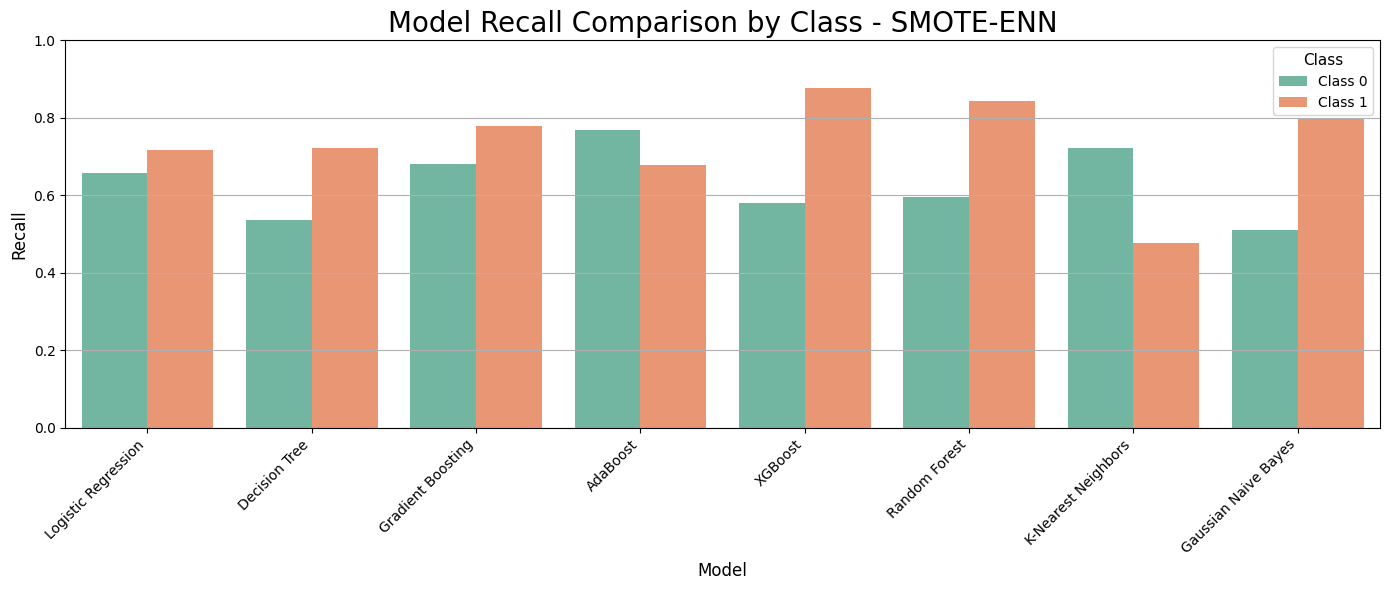

In [55]:
# Visualize Recall by Model and Class
results_df = pd.DataFrame(results)
# Reshape data for seaborn barplot
recall_data = []
for _, row in results_df.iterrows():
    recall_data.append({'Model': row['Model'], 'Class': 'Class 0', 'Recall': row['Class 0 Recall']})
    recall_data.append({'Model': row['Model'], 'Class': 'Class 1', 'Recall': row['Class 1 Recall']})

recall_df = pd.DataFrame(recall_data)

plt.figure(figsize=(14, 6))
sns.barplot(data=recall_df, x='Model', y='Recall', hue='Class', palette='Set2', errorbar=None)
plt.title('Model Recall Comparison by Class - SMOTE-ENN', fontsize=20,)
plt.ylim(0, 1)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Recall', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Class', title_fontsize=11)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

### **Dealing with Class Imbalance with Balanced Weights**

After unsatisfactory result when doing resampling, we decided to deal with class imbalance another way by balancing the weights of each class, meaning to give more weight to the minority class and let the model pay closer attention to it when learning.

In [34]:
# Models to test
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,          # Number of trees
        class_weight='balanced', 
        random_state=42
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200,          # Number of trees
        objective='binary:logistic',
        scale_pos_weight=0.15,
        random_state=42,
        eval_metric='aucpr'
    ),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=200, random_state=42),
}

results=[]
roc_data={}
# Train each model and store results
all_trained_models = {}
for name, model in models.items():
    print(f"{'-' * 100}\n\n--{name}--\n")
    trained_model = model_functionality(model, X_train, y_train, X_test, y_test, name)
    all_trained_models[name] = deepcopy(trained_model)


----------------------------------------------------------------------------------------------------

--Logistic Regression--

Accuracy on test data: 75%

F1 Score on test data: 0.84

Classification Report for Logistic Regression:

              precision    recall  f1-score   support

           0       0.30      0.73      0.42       198
           1       0.95      0.76      0.84      1402

    accuracy                           0.75      1600
   macro avg       0.63      0.74      0.63      1600
weighted avg       0.87      0.75      0.79      1600


----------------------------------------------------------------------------------------------------

--Random Forest--

Accuracy on test data: 88%

F1 Score on test data: 0.94

Classification Report for Random Forest:

              precision    recall  f1-score   support

           0       0.74      0.07      0.13       198
           1       0.88      1.00      0.94      1402

    accuracy                           0.88      1600
  

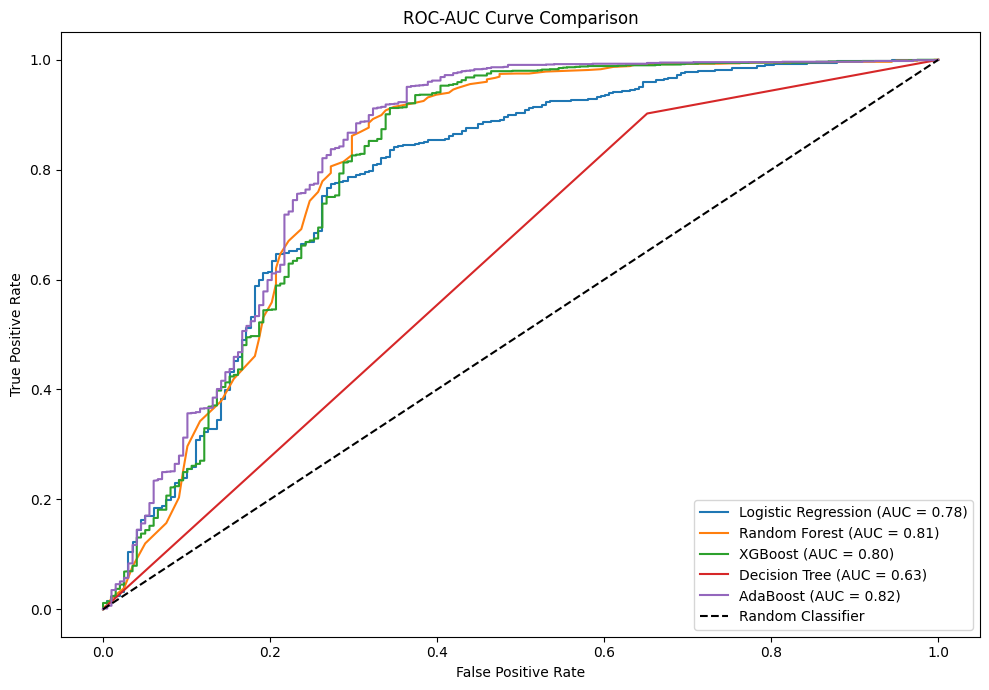

In [57]:
# Plot all ROC curves on one chart
plt.figure(figsize=(10, 7))
for model_name, (fpr, tpr, roc_auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve Comparison')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

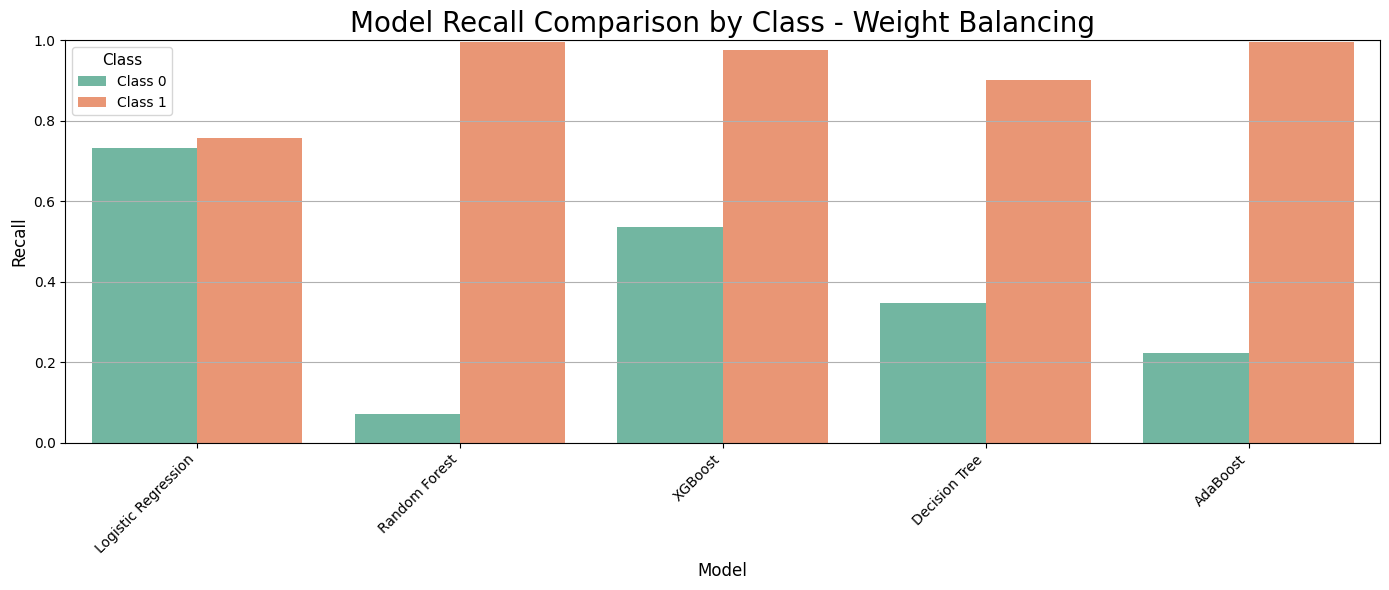

In [36]:
# Visualize Recall by Model and Class
results_df = pd.DataFrame(results)
# Reshape data for seaborn barplot
recall_data = []
for _, row in results_df.iterrows():
    recall_data.append({'Model': row['Model'], 'Class': 'Class 0', 'Recall': row['Class 0 Recall']})
    recall_data.append({'Model': row['Model'], 'Class': 'Class 1', 'Recall': row['Class 1 Recall']})

recall_df = pd.DataFrame(recall_data)

plt.figure(figsize=(14, 6))
sns.barplot(data=recall_df, x='Model', y='Recall', hue='Class', palette='Set2', errorbar=None)
plt.title('Model Recall Comparison by Class - Weight Balancing', fontsize=20,)
plt.ylim(0, 1)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Recall', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Class', title_fontsize=11)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

C:\Users\Asus\AppData\Local\Temp\ipykernel_9732\2011565889.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Model', y='Macro Avg F1', palette='husl', errorbar=None)


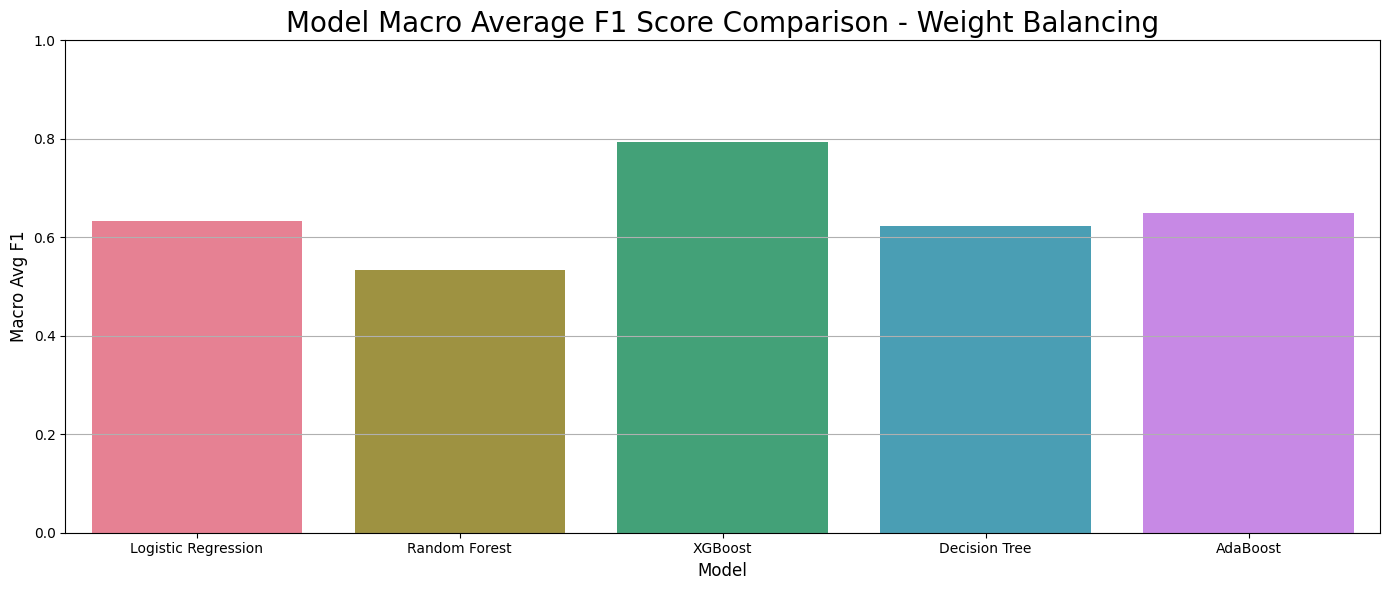

In [37]:
# Visualize Macro Avg F1 by Model
plt.figure(figsize=(14, 6))
sns.barplot(data=results_df, x='Model', y='Macro Avg F1', palette='husl', errorbar=None)
plt.title('Model Macro Average F1 Score Comparison - Weight Balancing', fontsize=20)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Macro Avg F1', fontsize=12)
plt.ylim(0,1)
plt.xticks(rotation=0, ha='center')
plt.grid(axis='y')
plt.tight_layout()
plt.show()


### **Choosing XGBoost**

We observe that XGBoost performs the best in every scenario we had so far, so we decided to go forth with it and try to do more optimization on it by tuning the hyperparameters and see if we can get a better performance out of it.

In [38]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [200, 300, 400],
    'max_depth': [4, 6, 8, 10],
    'learning_rate': [0.05, 0.1, 0.15],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'gamma': [0, 1, 2],
    'scale_pos_weight': [0.12, 0.15, 0.18]   
}
xgb = XGBClassifier(random_state=42, eval_metric='aucpr')
search = RandomizedSearchCV(xgb, param_grid, n_iter=30, cv=5, scoring='f1_macro', random_state=42, n_jobs=-1)
search.fit(X_train, y_train)
best_params = search.best_params_

print("Best Parameters:", best_params)

Best Parameters: {'subsample': 0.7, 'scale_pos_weight': 0.18, 'n_estimators': 300, 'max_depth': 8, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.8}


In [39]:
# 1. Get the best model
best_xgb = XGBClassifier(**best_params, random_state=42, eval_metric='aucpr')

# 2. Train the final model on FULL training data
best_xgb.fit(X_train, y_train)        

# 3. Make predictions on Test Set
y_pred = best_xgb.predict(X_test)
y_pred_proba = best_xgb.predict_proba(X_test)[:, 1]

# 4. Evaluate with multiple thresholds (Very Important!)
from sklearn.metrics import classification_report

thresholds = [0.43, 0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.50]
print("Threshold Tuning Results:\n")

for thresh in thresholds:
    y_pred_thresh = (y_pred_proba > thresh).astype(int)
    print(f"=== Threshold = {thresh} ===")
    print(classification_report(y_test, y_pred_thresh, 
                                target_names=["Class 0", "Class 1"]))
    print("-" * 50)

Threshold Tuning Results:

=== Threshold = 0.43 ===
              precision    recall  f1-score   support

     Class 0       0.86      0.52      0.65       198
     Class 1       0.94      0.99      0.96      1402

    accuracy                           0.93      1600
   macro avg       0.90      0.75      0.80      1600
weighted avg       0.93      0.93      0.92      1600

--------------------------------------------------
=== Threshold = 0.44 ===
              precision    recall  f1-score   support

     Class 0       0.85      0.53      0.65       198
     Class 1       0.94      0.99      0.96      1402

    accuracy                           0.93      1600
   macro avg       0.89      0.76      0.81      1600
weighted avg       0.93      0.93      0.92      1600

--------------------------------------------------
=== Threshold = 0.45 ===
              precision    recall  f1-score   support

     Class 0       0.83      0.54      0.65       198
     Class 1       0.94      0.99

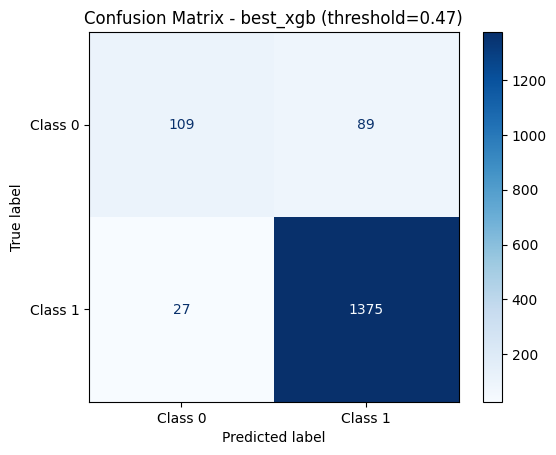

TN: 109, FP: 89, FN: 27, TP: 1375


In [40]:
# Confusion Matrix for best_xgb
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Use the same threshold logic from your tuning block
selected_threshold = 0.47
y_pred_best = (best_xgb.predict_proba(X_test)[:, 1] > selected_threshold).astype(int)

cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Class 0", "Class 1"])

disp.plot(cmap="Blues", values_format="d")
plt.title(f"Confusion Matrix - best_xgb (threshold={selected_threshold})")
plt.grid(False)
plt.show()

# Optional: print TN, FP, FN, TP for quick interpretation
tn, fp, fn, tp = cm.ravel()
print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")

In [ ]:
# For Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight


### **Build Neural Network Model**

In [ ]:

model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.4),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(1, activation='sigmoid')  # Binary Classification
])


c:\Users\Asus\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### **Compile Model**

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.0005),          
    loss='binary_crossentropy',
    metrics=['AUC']       
)

In [ ]:
# Calculate class weights

class_weights = compute_class_weight(
    class_weight='balanced', 
    classes=np.unique(y_train), 
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))

print("Class weights (higher for Class 0):", class_weight_dict)

Class weights (higher for Class 0): {0: np.float64(4.050632911392405), 1: np.float64(0.5704099821746881)}


In [ ]:
# Callbacks

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

### **Train Model**

In [ ]:
# Train with class weights

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    class_weight=class_weight_dict,     
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/100


80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - AUC: 0.7664 - Precision: 0.9440 - Recall: 0.7087 - loss: 0.5850 - val_AUC: 0.8292 - val_Precision: 0.9463 - val_Recall: 0.8917 - val_loss: 0.3989
Epoch 2/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - AUC: 0.7839 - Precision: 0.9427 - Recall: 0.7056 - loss: 0.5686 - val_AUC: 0.8290 - val_Precision: 0.9495 - val_Recall: 0.8678 - val_loss: 0.4174
Epoch 3/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - AUC: 0.7864 - Precision: 0.9476 - Recall: 0.7178 - loss: 0.5770 - val_AUC: 0.8293 - val_Precision: 0.9500 - val_Recall: 0.8607 - val_loss: 0.4225
Epoch 4/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - AUC: 0.7799 - Precision: 0.9465 - Recall: 0.7204 - loss: 0.5740 - val_AUC: 0.8304 - val_Precision: 0.9527 - val_Recall: 0.8580 - val_loss: 0.4239
Epoch 5/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.7860 - Precision: 0.9407 - Recall: 0.7209 - loss: 0.5732 - val_AUC: 0.8320 - val_Precision: 0.9504 - val_Recall: 0.8500 - val_loss: 0.4261
Epoch 6/100
80/80

In [ ]:
# Evaluate Model
y_pred = (model.predict(X_test) > 0.4).astype("int32")

# Compute F1-Scores
report = classification_report(y_test, y_pred, target_names=["Class 0", "Class 1"])
print(report)

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

     Class 0       0.46      0.51      0.49       198
     Class 1       0.93      0.92      0.92      1402

    accuracy                           0.87      1600
   macro avg       0.70      0.71      0.70      1600
weighted avg       0.87      0.87      0.87      1600



---

## **Features Importance Analysis from Best XGBoost Model**

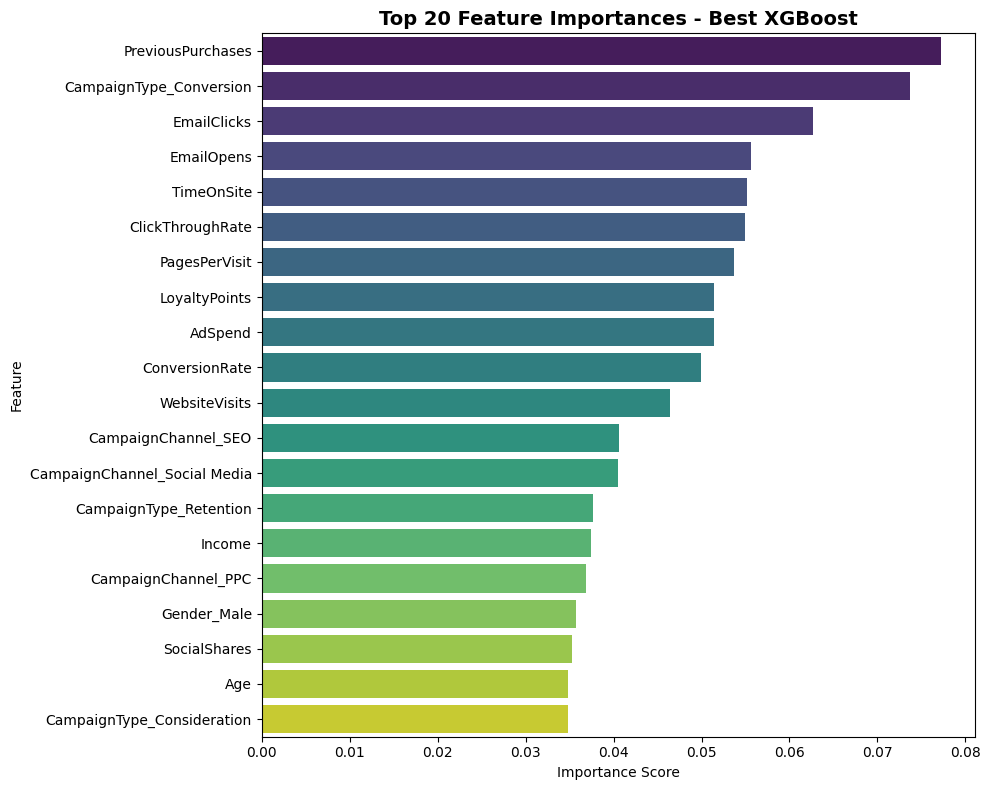

,Feature,Importance
11,PreviousPurchases,0.077178
19,CampaignType_Conversion,0.073744
10,EmailClicks,0.062706
9,EmailOpens,0.055643
7,TimeOnSite,0.055186
3,ClickThroughRate,0.054985
6,PagesPerVisit,0.053679
12,LoyaltyPoints,0.051390
2,AdSpend,0.051374
4,ConversionRate,0.049919


In [66]:
# Feature importances from the trained XGBoost model
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_xgb.feature_importances_
}).sort_values('Importance', ascending=False)

top_n = 20  
top_features = importance_df.head(top_n).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=top_features, x='Importance', y='Feature', palette='viridis', hue='Feature', legend=False)
plt.title(f'Top {top_n} Feature Importances - Best XGBoost', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

importance_df.head(10)

## Feature Importance Interpretation

The top 20 features from the tuned XGBoost model reveal a clear hierarchy
of what drives conversion prediction.

**Behavioural history dominates.** `PreviousPurchases`
is by far the strongest signal. A customer who has bought before is the model's strongest indicator of
likelihood to convert again. This aligns with the well-known marketing principle
that past behaviour is the best predictor of future behaviour.

**Campaign type matters.** `CampaignType_Conversion` is the second most important feature, reinforcing that being targeted with a conversion-focused campaign significantly boosts the likelihood of conversion. While other campaign types and channels are less predictive, this highlights the importance of campaign messaging and focus in driving conversions.

**Engagement signals form the second tier.** `EmailClicks`, `EmailOpens`,
`TimeOnSite`, `ClickThroughRate`, and `PagesPerVisit` all cluster closely together
in the 0.05–0.063 range. These are active engagement metrics. The model is
capturing that customers who interact meaningfully with content are more likely to
convert, as opposed to passive exposure.

**Spend and loyalty follow.** `LoyaltyPoints`, `AdSpend`, and `ConversionRate`
sit in the mid-tier, suggesting that investment in the customer relationship and
the customer's existing loyalty status both contribute, but are secondary to
direct behavioural signals.

**Channel type matter less than expected.** `CampaignChannel_SEO`,
`CampaignChannel_Social Media`, and `CampaignChannel_PPC` all score similarly
around 0.04, meaning the *channel* a customer comes from is less predictive than
*how they behave once they arrive*. This is an actionable insight, optimising
engagement quality likely matters more than channel mix.

**Demographics are the weakest predictors.** `Gender_Male`, `Age`, and `Income`
sit at the bottom of the top 20. This suggests the customer base converts
across demographic groups rather than within specific segments.

# **Conclusion**

Between all the different experimenations we did, we can conclude
- All resampling methods (Under/Over sampling) are not as effective as weight balancing, as they either lead to loss of information (undersampling) or overfitting (oversampling)
- XGBoost with balanced weights is the best performing model, achieving a good balance between precision and recall for both classes, and is the most suitable for this imbalanced classification problem.